In [33]:
import pandas as pd

# AAP daily OHLCV; path is relative to this notebook's working directory
csv_path = "./individual_stocks_5yr/AAP_data.csv"
df = pd.read_csv(csv_path)

# Quick sanity check: column names, dtypes, first rows
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,78.34,79.72,78.0100,78.90,1298137,AAP
1,2013-02-11,78.65,78.91,77.2300,78.39,758016,AAP
2,2013-02-12,78.39,78.63,77.5132,78.60,876859,AAP
3,2013-02-13,78.90,79.13,77.8500,78.97,1038574,AAP
4,2013-02-14,78.66,79.72,78.5850,78.84,1005376,AAP


In [34]:
# Null/NaN vs empty strings are separate: "" is not NaN in object columns
null_per_col = df.isna().sum()
print("Null / NaN count per column:")
print(null_per_col.to_string())

cols_with_nulls = null_per_col[null_per_col > 0]
print()
if len(cols_with_nulls):
    print("Columns with at least one missing value:")
    print(cols_with_nulls.to_string())
else:
    print("No null or NaN in any column (all counts are 0).")

# Empty = whitespace-stripped string length 0 (skip numeric/datetime dtypes)
def _n_empty_strings(col):
    if pd.api.types.is_numeric_dtype(col) or pd.api.types.is_datetime64_any_dtype(col):
        return 0
    return col.astype(str).str.strip().eq("").sum()

empty_per_col = df.apply(_n_empty_strings)
print()
print("Empty string count per column (after strip):")
print(empty_per_col.to_string())

cols_with_empty = empty_per_col[empty_per_col > 0]
print()
if len(cols_with_empty):
    print("Columns with at least one empty string:")
    print(cols_with_empty.to_string())
else:
    print("No empty strings in scanned text columns (all counts are 0).")

Null / NaN count per column:
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0

No null or NaN in any column (all counts are 0).

Empty string count per column (after strip):
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0

No empty strings in scanned text columns (all counts are 0).


In [35]:
import numpy as np
import pandas as pd

from sklearn.linear_model import HuberRegressor, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split

# Target: next-day simple return (decimal). Features at day t (then z-scored on train):
#   close, range (high-low), intraday_move (close-open), gap (open_t - close_{t-1}), log1p(volume)
# Ridge: pick alpha by time-series CV on the training set only (no peek at test).

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 1.5, 10]
time_series_cv = TimeSeriesSplit(n_splits=5)

df_multi = df.copy()
df_multi["return_next"] = (
    (df_multi["close"].shift(-1) - df_multi["close"]) / df_multi["close"]
)
df_multi["range_hl"] = df_multi["high"] - df_multi["low"]
df_multi["intraday_move"] = df_multi["close"] - df_multi["open"]
df_multi["gap"] = df_multi["open"] - df_multi["close"].shift(1)
df_multi["log_volume"] = np.log1p(df_multi["volume"])

# 1-day momentum
df_multi["prev_return"] = df_multi["close"].pct_change().shift(1)

# Volatility
df_multi["volatility_5d"] = df_multi["return_next"].shift(1).rolling(window=5).std()

# Volume Trend
df_multi["volume_momentum"] = df_multi["log_volume"] / df_multi["log_volume"].rolling(5).mean()

feature_column_names = [
    "close",
    "range_hl",
    "intraday_move",
    "gap",
    "log_volume",
]

df_multi = df_multi.dropna(subset=["return_next", "gap"])

columns_for_correlation = feature_column_names + ["return_next"]
correlation_matrix = df_multi[columns_for_correlation].corr()

features_raw = df_multi[feature_column_names].to_numpy()
target_return_next = df_multi["return_next"].to_numpy().reshape(-1, 1)
dates_row = pd.to_datetime(df_multi["date"])

(
    features_train_raw,
    features_test_raw,
    target_train,
    target_test,
    dates_train,
    dates_test,
) = train_test_split(
    features_raw,
    target_return_next,
    dates_row,
    test_size=0.2,
    shuffle=False,
)

n_train_samples = features_train_raw.shape[0]
feature_means = features_train_raw.mean(axis=0)
feature_stds = features_train_raw.std(axis=0)
features_train = (features_train_raw - feature_means) / feature_stds
features_test = (features_test_raw - feature_means) / feature_stds

mean_cv_rmse_by_alpha = []
for alpha in alphas:
    neg_mse_scores = cross_val_score(
        Ridge(alpha=alpha, fit_intercept=True),
        features_train,
        target_train.ravel(),
        cv=time_series_cv,
        scoring="neg_mean_squared_error",
    )
    mse_mean = -neg_mse_scores.mean()
    mean_cv_rmse_by_alpha.append(np.sqrt(mse_mean))

ridge_cv = RidgeCV(alphas=alphas, cv=time_series_cv, fit_intercept=True)
ridge_cv.fit(features_train, target_train.ravel())

predictions_train_final = ridge_cv.predict(features_train).reshape(-1, 1)
predictions_test = ridge_cv.predict(features_test).reshape(-1, 1)

r2_train = r2_score(target_train, predictions_train_final)
r2_test = r2_score(target_test, predictions_test)
rmse_train = float(np.sqrt(mean_squared_error(target_train, predictions_train_final)))
rmse_test = float(np.sqrt(mean_squared_error(target_test, predictions_test)))

residuals_test = (target_test - predictions_test).ravel()

huber = HuberRegressor(max_iter=200, alpha=ridge_cv.alpha_)
huber.fit(features_train, target_train.ravel())
predictions_test_huber = huber.predict(features_test).reshape(-1, 1)
rmse_test_huber = float(np.sqrt(mean_squared_error(target_test, predictions_test_huber)))


Correlation matrix (rounded):
               close  range_hl  intraday_move    gap  log_volume  return_next
close          1.000     0.321          0.032  0.005      -0.031       -0.058
range_hl       0.321     1.000          0.094 -0.148       0.510       -0.017
intraday_move  0.032     0.094          1.000  0.025       0.038        0.006
gap            0.005    -0.148          0.025  1.000      -0.071       -0.019
log_volume    -0.031     0.510          0.038 -0.071       1.000        0.024
return_next   -0.058    -0.017          0.006 -0.019       0.024        1.000


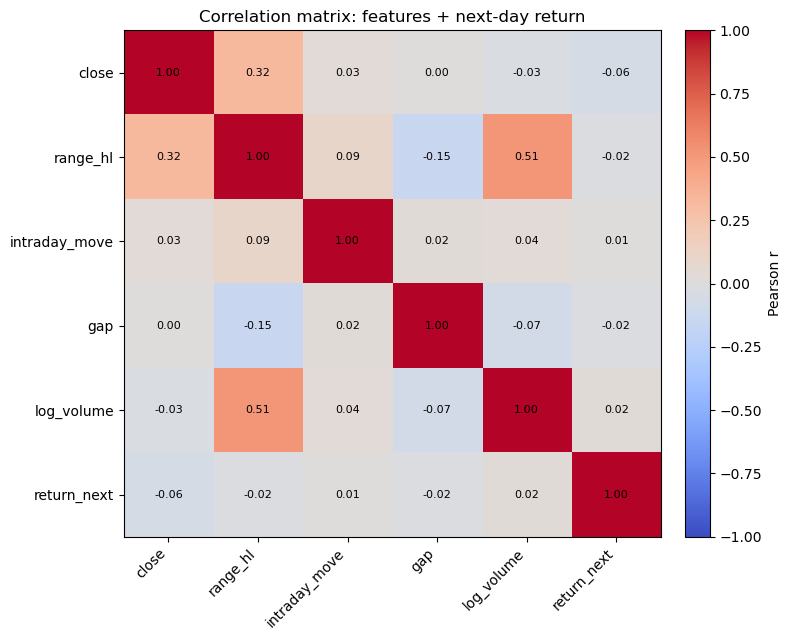

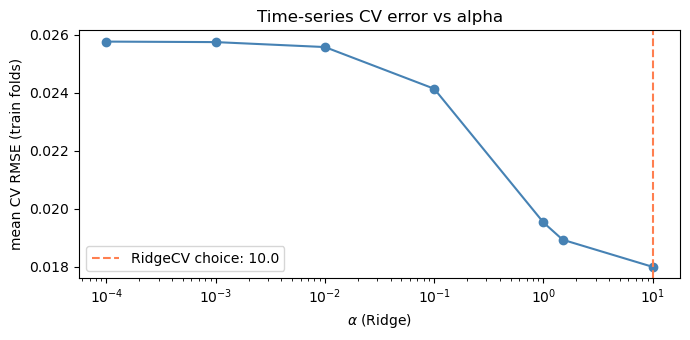

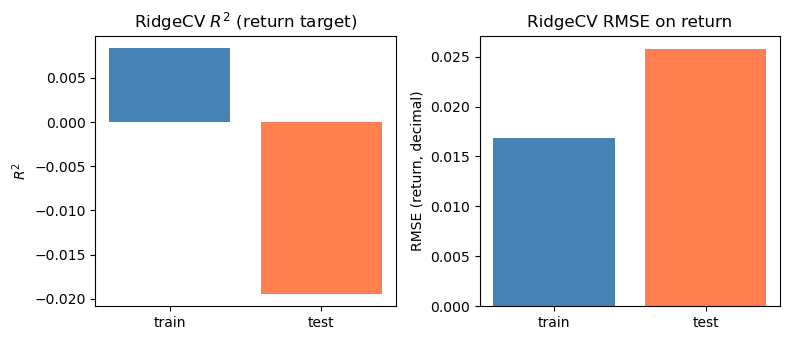

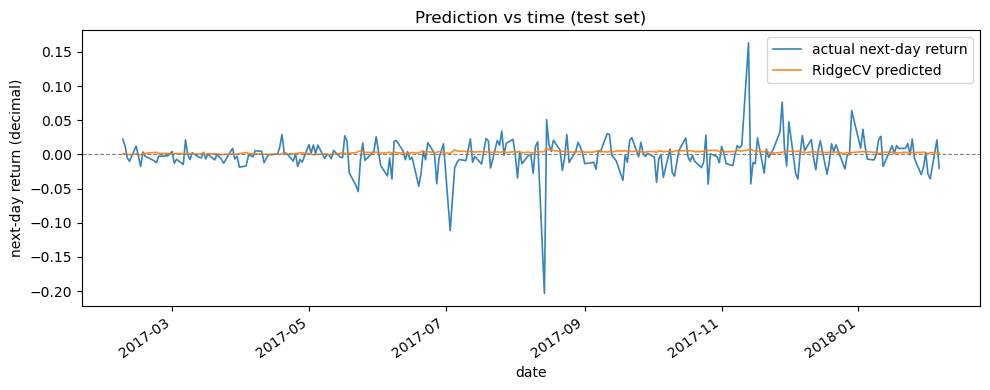

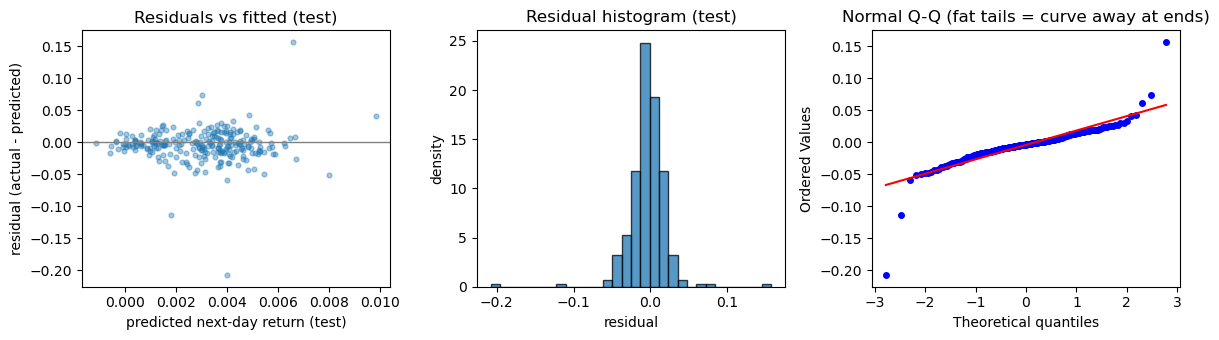

In [36]:
import matplotlib.pyplot as plt
import scipy.stats as st

# --- Plots (uses variables from setup cell: correlation_matrix, ridge_cv, predictions_*, etc.) ---
# Intermediate: correlation EDA between feature engineering and modeling is mirrored here after fit.

print("Correlation matrix (rounded):")
print(correlation_matrix.round(3))

fig_corr, ax_corr = plt.subplots(figsize=(8, 6.5))
heatmap = ax_corr.imshow(
    correlation_matrix.values,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)
ax_corr.set_xticks(range(len(correlation_matrix.columns)))
ax_corr.set_yticks(range(len(correlation_matrix.columns)))
ax_corr.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax_corr.set_yticklabels(correlation_matrix.columns)
for row_idx in range(len(correlation_matrix)):
    for col_idx in range(len(correlation_matrix)):
        ax_corr.text(
            col_idx,
            row_idx,
            f"{correlation_matrix.values[row_idx, col_idx]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )
fig_corr.colorbar(heatmap, ax=ax_corr, fraction=0.046, pad=0.04, label="Pearson r")
ax_corr.set_title("Correlation matrix: features + next-day return")
plt.tight_layout()
plt.show()

fig_alpha, ax_alpha = plt.subplots(figsize=(7, 3.5))
ax_alpha.semilogx(alphas, mean_cv_rmse_by_alpha, "o-", color="steelblue")
ax_alpha.axvline(ridge_cv.alpha_, color="coral", ls="--", label=f"RidgeCV choice: {ridge_cv.alpha_}")
ax_alpha.set_xlabel(r"$\alpha$ (Ridge)")
ax_alpha.set_ylabel("mean CV RMSE (train folds)")
ax_alpha.set_title("Time-series CV error vs alpha")
ax_alpha.legend()
plt.tight_layout()
plt.show()

fig_metrics, axes_metrics = plt.subplots(1, 2, figsize=(8, 3.5))
axes_metrics[0].bar(["train", "test"], [r2_train, r2_test], color=["steelblue", "coral"])
axes_metrics[0].set_ylabel(r"$R^2$")
axes_metrics[0].set_title(r"RidgeCV $R^2$ (return target)")
axes_metrics[1].bar(["train", "test"], [rmse_train, rmse_test], color=["steelblue", "coral"])
axes_metrics[1].set_ylabel("RMSE (return, decimal)")
axes_metrics[1].set_title("RidgeCV RMSE on return")
plt.tight_layout()
plt.show()

fig_time, ax_time = plt.subplots(figsize=(10, 4))
ax_time.plot(dates_test, target_test.ravel(), label="actual next-day return", lw=1.2, alpha=0.9)
ax_time.plot(
    dates_test,
    predictions_test.ravel(),
    label="RidgeCV predicted",
    lw=1.2,
    alpha=0.9,
)
ax_time.axhline(0.0, color="gray", lw=0.8, ls="--")
ax_time.set_xlabel("date")
ax_time.set_ylabel("next-day return (decimal)")
ax_time.set_title("Prediction vs time (test set)")
ax_time.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

fig_resid, axes_resid = plt.subplots(1, 3, figsize=(12, 3.5))
axes_resid[0].scatter(predictions_test.ravel(), residuals_test, s=12, alpha=0.4)
axes_resid[0].axhline(0.0, color="gray", lw=1)
axes_resid[0].set_xlabel("predicted next-day return (test)")
axes_resid[0].set_ylabel("residual (actual - predicted)")
axes_resid[0].set_title("Residuals vs fitted (test)")
axes_resid[1].hist(residuals_test, bins=30, edgecolor="black", alpha=0.75, density=True)
axes_resid[1].set_xlabel("residual")
axes_resid[1].set_ylabel("density")
axes_resid[1].set_title("Residual histogram (test)")
st.probplot(residuals_test, dist="norm", plot=axes_resid[2])
axes_resid[2].set_title("Normal Q-Q (fat tails = curve away at ends)")
axes_resid[2].get_lines()[0].set_markersize(4)
plt.tight_layout()
plt.show()


In [37]:
import numpy as np
import scipy.stats as st

# --- After plots: summary metrics and diagnostics (uses setup + plot cells) ---

skew_res = float(st.skew(residuals_test))
excess_kurt = float(st.kurtosis(residuals_test, fisher=True))
z_scores = (residuals_test - residuals_test.mean()) / residuals_test.std(ddof=0)
pct_gt3 = float(np.mean(np.abs(z_scores) > 3))

print(f"Test residual skew: {skew_res:.4f}  (0 if symmetric)")
print(
    f"Test residual excess kurtosis: {excess_kurt:.4f}  (0 for Gaussian; >0 => heavier tails)"
)
print(
    f"Fraction |standardized residual| > 3: {pct_gt3:.4f}  (~0.003 if Gaussian)"
)
print(
    f"Huber test RMSE: {rmse_test_huber:.6f}  vs Ridge test RMSE: {rmse_test:.6f}"
)

print(f"alphas tried: {alphas}")
print(f"RidgeCV selected alpha: {ridge_cv.alpha_}")
print(f"intercept: {ridge_cv.intercept_:.6f}")
for name, coef in zip(feature_column_names, ridge_cv.coef_):
    print(f"  coef[{name}]: {coef:.6f}  (standardized feature scale)")
print(f"R^2 train: {r2_train:.6f}  |  R^2 test: {r2_test:.6f}")
print(
    f"RMSE train: {rmse_train:.6f}  |  RMSE test: {rmse_test:.6f}  (return decimal; *100 for %)"
)


Test residual skew: -1.2509  (0 if symmetric)
Test residual excess kurtosis: 21.9638  (0 for Gaussian; >0 => heavier tails)
Fraction |standardized residual| > 3: 0.0159  (~0.003 if Gaussian)
Huber test RMSE: 0.025641  vs Ridge test RMSE: 0.025812
alphas tried: [0.0001, 0.001, 0.01, 0.1, 1, 1.5, 10]
RidgeCV selected alpha: 10.0
intercept: 0.000845
  coef[close]: -0.001218  (standardized feature scale)
  coef[range_hl]: -0.000201  (standardized feature scale)
  coef[intraday_move]: -0.000202  (standardized feature scale)
  coef[gap]: 0.000021  (standardized feature scale)
  coef[log_volume]: 0.001165  (standardized feature scale)
R^2 train: 0.008392  |  R^2 test: -0.019452
RMSE train: 0.016806  |  RMSE test: 0.025812  (return decimal; *100 for %)
